# Atari Pong - DQN Training

Deep Q-Network (DQN) training for Atari Pong using PyTorch with experience replay and target network.

In [ ]:
## Code piece to mount my Google Drive
from google.colab import drive
drive.mount("/content/drive") # my Google Drive root directory will be mapped here

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
# Change the working directory to your own work directory (where the code file is).
import os
thisdir = '/content/drive/MyDrive/hw4'
os.chdir(thisdir)

# Ensure the files are there (in the folder)
!pwd

/content/drive/MyDrive/hw4


## Install relevant libraries

In [63]:
%pip install -r requirements.txt

In [ ]:
import dqn_core # dqn_core.py
from dqn_core import AtariPreprocess, FrameStack, PongActionReducer, ReplayBuffer, DQN, make_env
import gymnasium as gym
import numpy as np
import random
import pickle

## Create an ale  (for display)

In [64]:
from ale_py import ALEInterface
ale = ALEInterface()

## 1. Create a DQN model (prediction/q_network and target_network) and load the pre-trained weights.  Also create the replay buffer and load the saved transitions.

Assume the q_net weight file is called **"q_net_XXXX.pt"** (where XXXX is the number of training steps, e.g. '700k' and '1M'), and it is found under the folder "checkpoints".  Note that this code is the same as the one in the evaluation code.

### Functions to load pretrained weights and replay buffer

In [65]:
def build_networks(n_actions, device):
    """Build the prediction and target networks."""
    q_net = DQN(n_actions).to(device)      # prediction network
    target_net = DQN(n_actions).to(device) # (frozen) target network
    return q_net, target_net

def load_pretrained(q_net, target_net, q_file, t_file, device):
    """Load pretrained weights from files for q_net and target_net.
       Move the tensors to device when loading."""
    q_net.load_state_dict(torch.load(q_file, map_location=device))
    target_net.load_state_dict(torch.load(t_file, map_location=device))
    target_net.eval() # target network does not 'learn'
    print(f"✅ Loaded pretrained networks from checkpoints")

def load_replay_buffer(pklfilepath):
    """Load replay buffer.  Assuming a .pkl file."""
    replay = ReplayBuffer.load(pklfilepath)
    #with open(pklfilepath, "rb") as f:
    #    replay = pickle.load(f)
    print(f"✅ Loaded replay buffer with {len(replay)} transitions")
    return replay


### **Initial** calls to those functions to load models and reply buffer.  Also create an environment.

In [66]:
import torch # define GPU access
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# folder and filenames for pretrained weights and reply buffer
checkpoint_dir = "checkpoints"

# (*) Initial checkpoint info
START_STEP = 700_000
str_steps = "_700k"

qnet_file = f"{checkpoint_dir}/q_net{str_steps}.pt"
target_file = f"{checkpoint_dir}/target_net{str_steps}.pt"
replay_file = f"{checkpoint_dir}/replay{str_steps}.pkl"

#------------------------------
# create an environment
env = make_env() # default env; function in dqn_core.py
n_actions = env.action_space.n
print(f"✅ Number of actions: {n_actions}")

# load pretrained model weights
q_net, target_net = build_networks(n_actions, DEVICE)
load_pretrained(q_net, target_net, qnet_file, target_file, DEVICE)

# Define optimizer here, after q_net is instantiated
import torch # Ensure torch is imported if not already
optimizer = torch.optim.Adam(q_net.parameters(), lr=1e-4)

# Load the pre-loaded replay buffer
buffer = load_replay_buffer(replay_file)

✅ Number of actions: 4
✅ Loaded pretrained networks from checkpoints
✅ Loaded replay buffer with 100000 transitions


## 2. Further training
### 2.0 Declare global constants

In [67]:
import torch.optim as optim

# Hyperparameters (students may tune)
GAMMA = 0.99
BATCH_SIZE = 32
BUFFER_SIZE = 100_000
LEARNING_RATE = 1e-4
TARGET_UPDATE_FREQ = 10_000
LEARNING_STARTS = 50_000
TOTAL_STEPS = 300_000

EPS_START = 1.0
EPS_END = 0.1
EPS_DECAY = 1_500_000  # divisor to the current steps (e.g. 700,000 / 1,500,000 = 0.467)

### 2.1 select_action -- Epsilon-greedy strategy

In [68]:
def select_action(state, current_steps):
    ## (*) TODO:
    ## Implement epsilon-greedy exploration.  It computes the epsilon as
    ## current steps divided by EPS_DECAY subtracted from EPS_START, or
    ## EPS_END, whichever the largest.
    ## Hint: Look at the evaluation section for the code for greedy choice.
    ##
    current_epsilon = max(EPS_END, EPS_START - current_steps / EPS_DECAY) # computing epsilon based on current steps
    if random.random() < current_epsilon: # checking if random exploration should occur and selecting action
        selected_action = env.action_space.sample()
    else:
        with torch.no_grad(): # disabling gradient computation for inference
            state_tensor = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0) # converting state to tensor and adding batch dimension
            selected_action = q_net(state_tensor).argmax(1).item() # selecting action with highest Q-value

    return selected_action

### 2.2 Optimization (and backprop) step

In [69]:
import torch.nn.functional as F

def optimize():
    if len(buffer) < BATCH_SIZE:
        return

    ## (*) TODO
    ## Obtain BATCH_SIZE number of transitions from the reply buffer.
    ## states, actions, rewards, next_states, dones = ...
    ##

    states,actions,rewards,next_states,dones = buffer.sample(BATCH_SIZE) # sampling transitions from replay

    states = torch.tensor(states, device=DEVICE)
    actions = torch.tensor(actions, device=DEVICE).unsqueeze(1)
    rewards = torch.tensor(rewards, device=DEVICE)
    next_states = torch.tensor(next_states, device=DEVICE)
    # Convert dones to float32
    dones = torch.tensor(dones, dtype=torch.float32, device=DEVICE)

    # Q(s, a): From the Q-network's output, pick the Q-value corresponding
    # to the action that was actually taken, for each state in the batch.
    # 'q_net(states)' where states is of shape (B, 4, 84, 84), returns
    # q-values of the form '[[ 1.2, -0.4,  0.7,  3.5], [ 0.1,  0.9, -0.2,  0.4],..'
    # 'gather(1,actions)' returns [[3.5], [0.9],..], and squeeze(1) makes
    # into a 1-D array [3.5, 0.9,..]
    q_values = q_net(states).gather(1, actions).squeeze(1)

    # max_a' Q_target(s', a')
    with torch.no_grad():
        next_q_values = target_net(next_states).max(1)[0]

    ## (*) TODO
    ## Compute the target values (based on the algorithm).
    ## target = ...
    ##
    target = rewards+GAMMA*next_q_values*(1-dones) # using equation

    # compute the loss
    loss = F.smooth_l1_loss(q_values, target)

    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

updated - Helper function to detect ball position for hit counting

In [70]:
def detect_ball(obs):
    if obs.max() <= 1.0: # checking if observation needs scaling
        obs = (obs * 255).astype(np.uint8)
    _, thresh = cv2.threshold(obs, 200, 255, cv2.THRESH_BINARY) # applying binary threshold to isolate bright objects
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(thresh, connectivity=8)
    candidates = [] #  potential ball candidates
    for i in range(1, num_labels): # looping through each detected component
        area = stats[i, cv2.CC_STAT_AREA]
        cx, cy = centroids[i] # getting centroid coordinates of current component
        if 2 <= area <= 50: # if component size matches ball dimensions
            candidates.append((area, cx, cy))
    if not candidates:
        return None
    _, ball_x, ball_y = min(candidates, key=lambda x: x[0]) # selecting smallest candidate as ball
    return int(ball_x), int(ball_y)

## 3. Main Training Loop

In [71]:
def do_train(start_step):
    episode_reward = 0 # initializing reward counter for current episode
    # updating
    all_episode_rewards = [] # list to track rewards per episode
    all_episode_hits = [] #  list to track hits per episode
    current_episode_hits = 0 # hit counter for current episode
    previous_ball_x = None #  previous ball x-position
    previous_ball_dx = None # previous ball velocity
    #
    obs, info = env.reset()
    # FIRE to start Pong
    obs, _, _, _, _ = env.step(1)

    for step in range(start_step + 1, start_step + TOTAL_STEPS + 1):
        if step % 1000 == 0:
            print(f"Step {step}")

        ## (*) TODO
        ## Select action based on the epsilon-greedy policy.
        ## action = ...
        action = select_action(obs,step) # selecting action
        # take the action
        next_obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        ## (*) TODO:
        ## Store transition in replay buffer
        ##
        buffer.push(obs, action, reward, next_obs, done) # storing transition in replay buffer
        obs = next_obs
        episode_reward += reward
        # updating
        # detecting ball and tracking hits
        latest_frame = obs[-1] # getting last frame in stack
        detected_ball = detect_ball(latest_frame) # detecting ball position in current frame
        if detected_ball is not None:
            current_ball_x, current_ball_y = detected_ball
            if previous_ball_x is not None:
                current_ball_dx = current_ball_x - previous_ball_x # computing ball velocity
                if previous_ball_dx is not None:
                    if previous_ball_dx > 0 and current_ball_dx < 0 and 40 <= current_ball_x <= 65: # detecting right paddle hit via velocity reversal
                        current_episode_hits += 1
                previous_ball_dx = current_ball_dx # updating previous velocity
            previous_ball_x = current_ball_x # updating previous x-position
        #
        # if step > LEARNING_STARTS:
        optimize()

        ## (*) TODO
        ## Periodically update target network (TARGET_UPDATE_FREQ).
        ##
        ##
        ##
        if step % TARGET_UPDATE_FREQ == 0: # checking if target network should be updated
            target_net.load_state_dict(q_net.state_dict()) # copying weights from q_net to target_net
            print(f" updated target network at step {step}")

        if done:
            print(f"Step {step}: episode reward = {episode_reward}, hits = {current_episode_hits}")
            #updating
            all_episode_rewards.append(episode_reward) # recording episode reward and hits
            all_episode_hits.append(current_episode_hits)
            #
            obs, info = env.reset()
            # FIRE to start Pong
            obs, _, _, _, _ = env.step(1)
            episode_reward = 0
            #updating
            current_episode_hits = 0 # resetting
            previous_ball_x = None
            previous_ball_dx = None
            #
    return all_episode_rewards, all_episode_hits

## 3.1 **Run do_train()** by executing the cell below.

In [72]:
# updating
import cv2
# Train further TOTAL_STEPS number of steps
rewards,hits = do_train(START_STEP)
print(f"\n training complete (700k - 1M)")
print(f"Episodes completed: {len(rewards)}")
print(f"Average reward: {np.mean(rewards):.2f}")
print(f"Average hits: {np.mean(hits):.2f}")

Step 701000
Step 702000
Step 703000
Step 704000
Step 704495: episode reward = -21.0, hits = 13
Step 705000
Step 706000
Step 707000
Step 708000
Step 709000
Step 709834: episode reward = -21.0, hits = 18
Step 710000
 updated target network at step 710000
Step 711000
Step 712000
Step 713000
Step 714000
Step 714576: episode reward = -20.0, hits = 14
Step 715000
Step 716000
Step 717000
Step 718000
Step 719000
Step 719521: episode reward = -19.0, hits = 10
Step 720000
 updated target network at step 720000
Step 721000
Step 722000
Step 723000
Step 724000
Step 724087: episode reward = -20.0, hits = 4
Step 725000
Step 726000
Step 727000
Step 727630: episode reward = -21.0, hits = 1
Step 728000
Step 729000
Step 730000
 updated target network at step 730000
Step 731000
Step 732000
Step 733000
Step 733212: episode reward = -20.0, hits = 10
Step 734000
Step 735000
Step 736000
Step 737000
Step 737654: episode reward = -20.0, hits = 11
Step 738000
Step 739000
Step 740000
 updated target network at st

## 4. Visualize the further-trained model (one episode)

In [73]:
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import time

def visualize_one_episode(model, env):
    obs, info = env.reset()
    obs, _, _, _, _ = env.step(1)  # FIRE to start the game

    # set up the visualization variables (fig, img, ax)
    fig, ax = plt.subplots(figsize=(4, 4))
    img = ax.imshow(env.render())
    ax.axis("off")

    display_handle = display(fig, display_id=True) # set up display_handle

    frames = [] # collect frames for a video

    # (*) start an episode (until either player reaches 21 points)
    # actions were chosen by the greedy strategy, selecting the action with the
    # largest value produced on the output layer of the model (q_net).
    done = False
    total_reward = 0

    while not done:
        with torch.no_grad():
            # tranform obs (4, 84, 84) to a batch (of one instance)
            state = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)

            # (*) select action with the highest Q-value for the current state.
            action = model(state).argmax(1).item()
            # q_net(state) returns model output, which is a tensor containing
            # values of the actions, e.g. 'tensor([[ 1.2, -0.4,  0.7,  3.5]])',
            # where the inner list is the average rewards of the actions.
            # Then .argmax(1) returns 'tensor([3])', then by .item(), we get 3,
            # the action number of the 'best' action.

        # take the action and receive info from the environment
        obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward

        # visualization
        frame = env.render()
        frames.append(frame) # updating
        img.set_data(frame)
        display_handle.update(fig)

        time.sleep(0.03)

    plt.close(fig)
    env.close()

    print("Total reward:", total_reward)
    return frames, total_reward


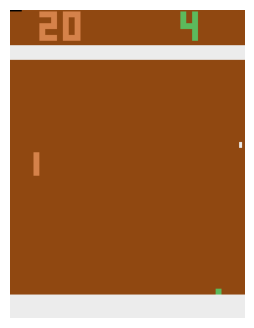

Total reward: -17.0


In [74]:
# Call the visualization function (with the last model/q_net)
env = make_env(render_mode="rgb_array") # for visual rendering

model = DQN(n_actions).to(DEVICE)
model.load_state_dict(q_net.state_dict())
model.eval()

frames, total_reward = visualize_one_episode(q_net, env)

## 5. Save the model (q_net and target_net) and the replay buffer

In [75]:
steps = "_1M"
qnet_file = f"{checkpoint_dir}/q_net{steps}.pt"
target_file = f"{checkpoint_dir}/target_net{steps}.pt"
replay_file = f"{checkpoint_dir}/replay{steps}.pkl"

torch.save(q_net.state_dict(), qnet_file)
torch.save(target_net.state_dict(), target_file)
buffer.save(replay_file)

env.close()

## 6. Create a video and save it

In [76]:
import imageio

video_dir = "/content/drive/MyDrive/hw4/videos"
video_path = f"{video_dir}/pong{steps}.mp4"
imageio.mimsave(video_path, frames, fps=30)
print(f"Saved video to {video_path}")


Saved video to /content/drive/MyDrive/hw4/videos/pong_1M.mp4


## Step-4:
## Continuing Training from 1M to 2.5M

In [79]:
checkpoint_steps = [700_000, 1_000_000] # checkpoints we have
checkpoint_rewards = []
checkpoint_hits = []
# storing 700k-1M performance
checkpoint_rewards.append(np.mean(rewards))
checkpoint_rewards.append(np.mean(rewards))
checkpoint_hits.append(np.mean(hits))
checkpoint_hits.append(np.mean(hits))
print(f"700k-1M performance stored: Reward={np.mean(rewards):.2f}, Hits={np.mean(hits):.2f}\n")

# training parameters
current_step = 1_000_000 # starting from 1M to 2.5M
final_step = 2_500_000
step_size = TOTAL_STEPS # TOTAL_STEPS = 300_000
while current_step < final_step:
    next_step = current_step + step_size # computing next checkpoint
    print(f"Training: {current_step:,} - {next_step:,}")
    chunk_rewards, chunk_hits = do_train(current_step) # training and getting performance
    # saving checkpoint
    step_label = f"_{next_step//1000}k"
    torch.save(q_net.state_dict(), f"{checkpoint_dir}/q_net{step_label}.pt") # saving q_net
    torch.save(target_net.state_dict(), f"{checkpoint_dir}/target_net{step_label}.pt") # saving target_net
    buffer.save(f"{checkpoint_dir}/replay{step_label}.pkl") # saving buffer
    # storing performance for chart
    checkpoint_steps.append(next_step)
    checkpoint_rewards.append(np.mean(chunk_rewards))
    checkpoint_hits.append(np.mean(chunk_hits))
    print(f"\nCheckpoint saved at {next_step:,}")
    print(f"Performance: Reward={np.mean(chunk_rewards):.2f}, Hits={np.mean(chunk_hits):.2f}")
    current_step = next_step # updating step and START_STEP
    START_STEP = next_step

700k-1M performance stored: Reward=-19.04, Hits=16.11

Training: 1,000,000 - 1,300,000
Step 1001000
Step 1002000
Step 1003000
Step 1004000
Step 1005000
Step 1006000
Step 1006888: episode reward = -18.0, hits = 17
Step 1007000
Step 1008000
Step 1009000
Step 1010000
 updated target network at step 1010000
Step 1011000
Step 1012000
Step 1013000
Step 1013916: episode reward = -20.0, hits = 17
Step 1014000
Step 1015000
Step 1016000
Step 1017000
Step 1018000
Step 1019000
Step 1020000
 updated target network at step 1020000
Step 1020942: episode reward = -18.0, hits = 16
Step 1021000
Step 1022000
Step 1023000
Step 1024000
Step 1025000
Step 1026000
Step 1026589: episode reward = -20.0, hits = 22
Step 1027000
Step 1028000
Step 1029000
Step 1030000
 updated target network at step 1030000
Step 1031000
Step 1032000
Step 1033000
Step 1033857: episode reward = -18.0, hits = 20
Step 1034000
Step 1035000
Step 1036000
Step 1037000
Step 1038000
Step 1039000
Step 1040000
 updated target network at step 1

## Plotting Performance Chart

Evaluating all checkpoints for consistent comparison...

Evaluating 700k checkpoint...
  700k: Reward=-20.00, Hits=9.00

Evaluating 1000k checkpoint...
  1000k: Reward=-17.00, Hits=26.00

Evaluating 1300k checkpoint...
  1300k: Reward=-13.00, Hits=25.00

Evaluating 1600k checkpoint...
  1600k: Reward=-13.00, Hits=41.00

Evaluating 1900k checkpoint...
  1900k: Reward=-9.00, Hits=36.00

Evaluating 2200k checkpoint...
  2200k: Reward=-15.00, Hits=17.00

Evaluating 2500k checkpoint...
  2500k: Reward=-14.00, Hits=36.00


CONSISTENT EVALUATION RESULTS (700k → 2.5M)
Checkpoint      Avg Reward      Avg Hits       
---------------------------------------------
700k            -20.00          9.00           
1000k           -17.00          26.00          
1300k           -13.00          25.00          
1600k           -13.00          41.00          
1900k           -9.00           36.00          
2200k           -15.00          17.00          
2500k           -14.00          36.00          



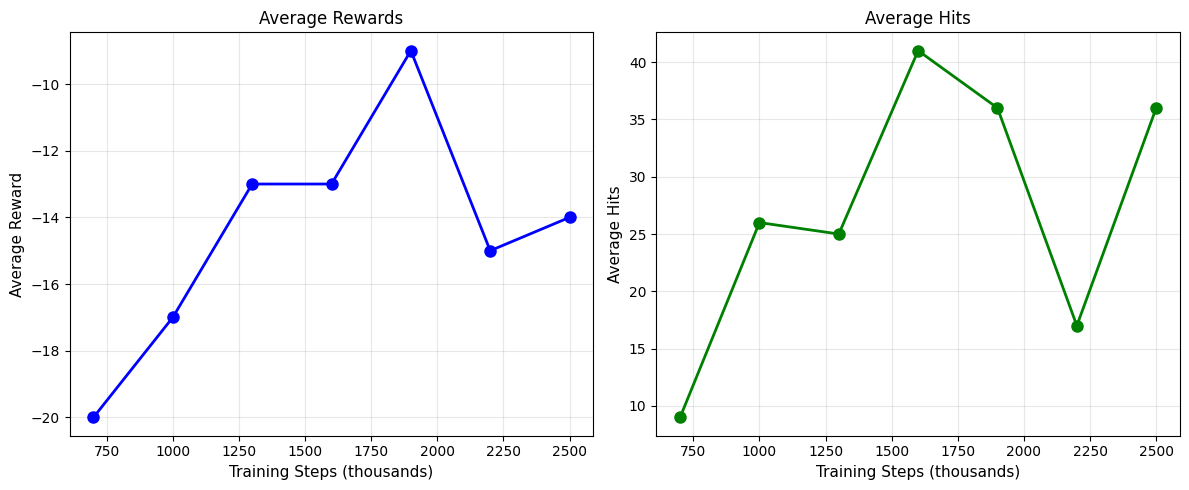

In [87]:
# Evaluate ALL checkpoints consistently
print("Evaluating all checkpoints for consistent comparison...\n")

all_checkpoints = [700_000, 1_000_000, 1_300_000, 1_600_000, 1_900_000, 2_200_000, 2_500_000]
checkpoint_rewards_eval = []
checkpoint_hits_eval = []

for step in all_checkpoints:
    print(f"Evaluating {step//1000}k checkpoint...")

    # Special handling for 1M filename
    if step == 1_000_000:
        filename = f"{checkpoint_dir}/q_net_1M.pt"
    else:
        filename = f"{checkpoint_dir}/q_net_{step//1000}k.pt"

    # Load model
    model_eval = DQN(n_actions).to(DEVICE)
    model_eval.load_state_dict(torch.load(filename, map_location=DEVICE))
    model_eval.eval()

    # Run 3 episodes
    step_rewards = []
    step_hits = []

    for ep in range(3):
        env_eval = make_env()
        obs, _ = env_eval.reset()
        obs, _, _, _, _ = env_eval.step(1)

        ep_reward = 0
        ep_hits = 0
        done = False
        prev_x = None
        prev_dx = None

        while not done:
            with torch.no_grad():
                state = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
                action = model_eval(state).argmax(1).item()

            obs, rew, terminated, truncated, _ = env_eval.step(action)
            done = terminated or truncated
            ep_reward += rew

            # Hit counting
            frame = obs[-1]
            ball = detect_ball(frame)
            if ball:
                curr_x, curr_y = ball
                if prev_x is not None:
                    curr_dx = curr_x - prev_x
                    if prev_dx and prev_dx > 0 and curr_dx < 0 and 40 <= curr_x <= 65:
                        ep_hits += 1
                    prev_dx = curr_dx
                prev_x = curr_x

        env_eval.close()
        step_rewards.append(ep_reward)
        step_hits.append(ep_hits)

    checkpoint_rewards_eval.append(np.mean(step_rewards))
    checkpoint_hits_eval.append(np.mean(step_hits))
    print(f"  {step//1000}k: Reward={np.mean(step_rewards):.2f}, Hits={np.mean(step_hits):.2f}\n")

# Update arrays
checkpoint_steps = all_checkpoints
checkpoint_rewards = checkpoint_rewards_eval
checkpoint_hits = checkpoint_hits_eval

# Display summary
print("\n" + "="*60)
print("CONSISTENT EVALUATION RESULTS (700k → 2.5M)")
print("="*60)
print(f"{'Checkpoint':<15} {'Avg Reward':<15} {'Avg Hits':<15}")
print(f"{'-'*45}")

for i in range(len(checkpoint_steps)):
    step_k = f"{checkpoint_steps[i]//1000}k"
    print(f"{step_k:<15} {checkpoint_rewards[i]:<15.2f} {checkpoint_hits[i]:<15.2f}")

print()

# Plot
steps_k = [s/1000 for s in checkpoint_steps]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(steps_k, checkpoint_rewards, 'b-o', linewidth=2, markersize=8)
axes[0].set_title('Average Rewards', fontsize=12)
axes[0].set_xlabel('Training Steps (thousands)', fontsize=11)
axes[0].set_ylabel('Average Reward', fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(steps_k, checkpoint_hits, 'g-o', linewidth=2, markersize=8)
axes[1].set_title('Average Hits', fontsize=12)
axes[1].set_xlabel('Training Steps (thousands)', fontsize=11)
axes[1].set_ylabel('Average Hits', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Performance summary (700k - 2.5M)
Checkpoint      Evaluation Reward   
700k            -19.037037037037038 
1000k           -19.037037037037038 
1300k           -16.558823529411764 
1600k           -14.375             
1900k           -12.590909090909092 
2200k           -12.72              
2500k           -12.625             


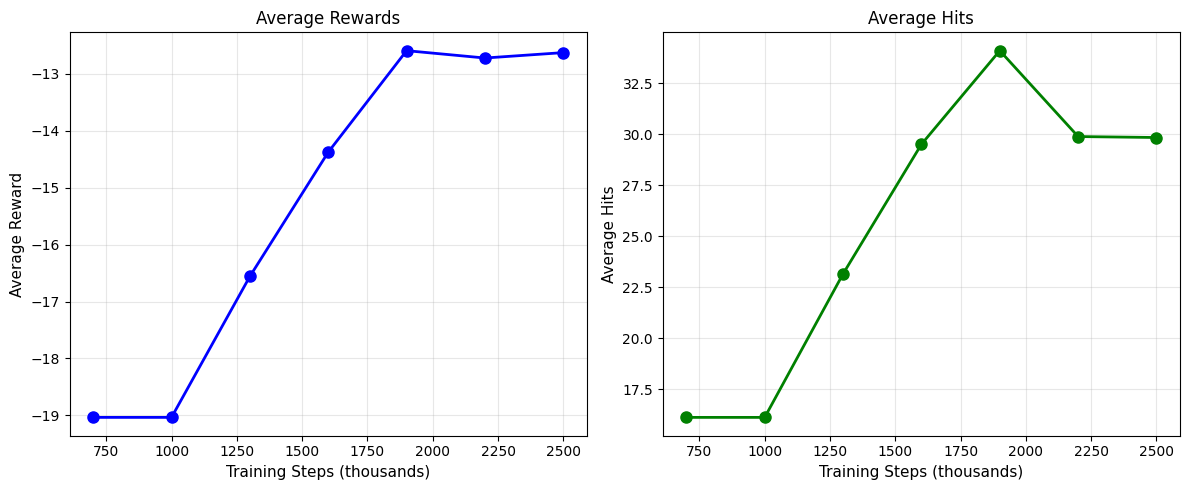

In [80]:
print("Performance summary (700k - 2.5M)")
print(f"{'Checkpoint':<15} {'Evaluation Reward':<20}")
for i in range(min(len(checkpoint_steps), len(checkpoint_rewards))): # looping through checkpoints, ensuring aligned lengths
    step_k = f"{checkpoint_steps[i]//1000}k" # formatting
    print(f"{step_k:<15} {checkpoint_rewards[i]:<20}")
# plotting
steps_k = [s/1000 for s in checkpoint_steps[:len(checkpoint_rewards)]] # converting to thousands and aligning length
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# rewards
axes[0].plot(steps_k, checkpoint_rewards, 'b-o', linewidth=2, markersize=8)
axes[0].set_title('Average Rewards', fontsize=12)
axes[0].set_xlabel('Training Steps (thousands)', fontsize=11)
axes[0].set_ylabel('Average Reward', fontsize=11)
axes[0].grid(True, alpha=0.3)
# hits
axes[1].plot(steps_k, checkpoint_hits, 'g-o', linewidth=2, markersize=8)
axes[1].set_title('Average Hits', fontsize=12)
axes[1].set_xlabel('Training Steps (thousands)', fontsize=11)
axes[1].set_ylabel('Average Hits', fontsize=11)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Saving Video

Generating video: 1900k checkpoint


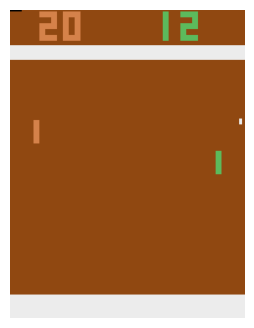

Total reward: -9.0
Episode reward: -9.0

 Video saved: /content/drive/MyDrive/hw4/videos/pong_1900k.mp4



In [89]:
video_step = 1_900_000  # since this checkpoint gave better performance
print(f"Generating video: {video_step//1000}k checkpoint")
video_suffix = f"_{video_step//1000}k" # creating suffix
video_model = DQN(n_actions).to(DEVICE) # creating model
video_model.load_state_dict(torch.load(f"{checkpoint_dir}/q_net{video_suffix}.pt", map_location=DEVICE))
video_model.eval()
env = make_env(render_mode="rgb_array") # creating environment
frames, video_reward = visualize_one_episode(video_model, env) # using existing function
print(f"Episode reward: {video_reward}")

video_filename = f"pong_{video_step//1000}k.mp4" # creating filename
video_path = f"{video_dir}/{video_filename}"
imageio.mimsave(video_path, frames, fps=30)
print(f"\n Video saved: {video_path}\n")